<a href="https://colab.research.google.com/github/istackdatabase/Machine-learning-project/blob/main/diabetes_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# necessary package include
import warnings
warnings.filterwarnings("ignore")  # ignore all warnings
import pandas as pd
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('/content/diabetes_dataset.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     10000 non-null  int64  
 1   Age                            10000 non-null  int64  
 2   Sex                            10000 non-null  object 
 3   Ethnicity                      10000 non-null  object 
 4   BMI                            10000 non-null  float64
 5   Waist_Circumference            10000 non-null  float64
 6   Fasting_Blood_Glucose          10000 non-null  float64
 7   HbA1c                          10000 non-null  float64
 8   Blood_Pressure_Systolic        10000 non-null  int64  
 9   Blood_Pressure_Diastolic       10000 non-null  int64  
 10  Cholesterol_Total              10000 non-null  float64
 11  Cholesterol_HDL                10000 non-null  float64
 12  Cholesterol_LDL                10000 non-null  

In [5]:
df.head()

,Unnamed: 0,Age,Sex,Ethnicity,BMI,Waist_Circumference,Fasting_Blood_Glucose,HbA1c,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,...,Cholesterol_HDL,Cholesterol_LDL,GGT,Serum_Urate,Physical_Activity_Level,Dietary_Intake_Calories,Alcohol_Consumption,Smoking_Status,Family_History_of_Diabetes,Previous_Gestational_Diabetes
0,0,58,Female,White,35.8,83.4,123.9,10.9,152,114,...,50.2,99.2,37.5,7.2,Moderate,1538,Moderate,Never,0,1
1,1,48,Male,Asian,24.1,71.4,183.7,12.8,103,91,...,62.0,146.4,88.5,6.1,Moderate,2653,Moderate,Current,0,1
2,2,34,Female,Black,25.0,113.8,142.0,14.5,179,104,...,32.1,164.1,56.2,6.9,Low,1684,Heavy,Former,1,0
3,3,62,Male,Asian,32.7,100.4,167.4,8.8,176,118,...,41.1,84.0,34.4,5.4,Low,3796,Moderate,Never,1,0
4,4,27,Female,Asian,33.5,110.8,146.4,7.1,122,97,...,53.9,92.8,81.9,7.4,Moderate,3161,Heavy,Current,0,0


In [6]:
# drop coloumn ,Remove unnecessary column
df=df.drop(['Unnamed: 0'], axis=1)
#df = df.drop(['Unnamed: 0'], axis=1)


In [7]:
df.isnull().sum()

,0
Age,0
Sex,0
Ethnicity,0
BMI,0
Waist_Circumference,0
Fasting_Blood_Glucose,0
HbA1c,0
Blood_Pressure_Systolic,0
Blood_Pressure_Diastolic,0
Cholesterol_Total,0


In [8]:
# Handling Missing Values: Alcohol_Consumption
df['Alcohol_Consumption'] = df['Alcohol_Consumption'].fillna("unknown")

In [9]:
# Identifying duplications
df.duplicated().sum()

np.int64(0)

In [10]:
#Summarise numerial features
numeric_df = df.select_dtypes(include=[np.number])
numeric_df = df.describe()
categorical_df = df.select_dtypes(include=["object"])

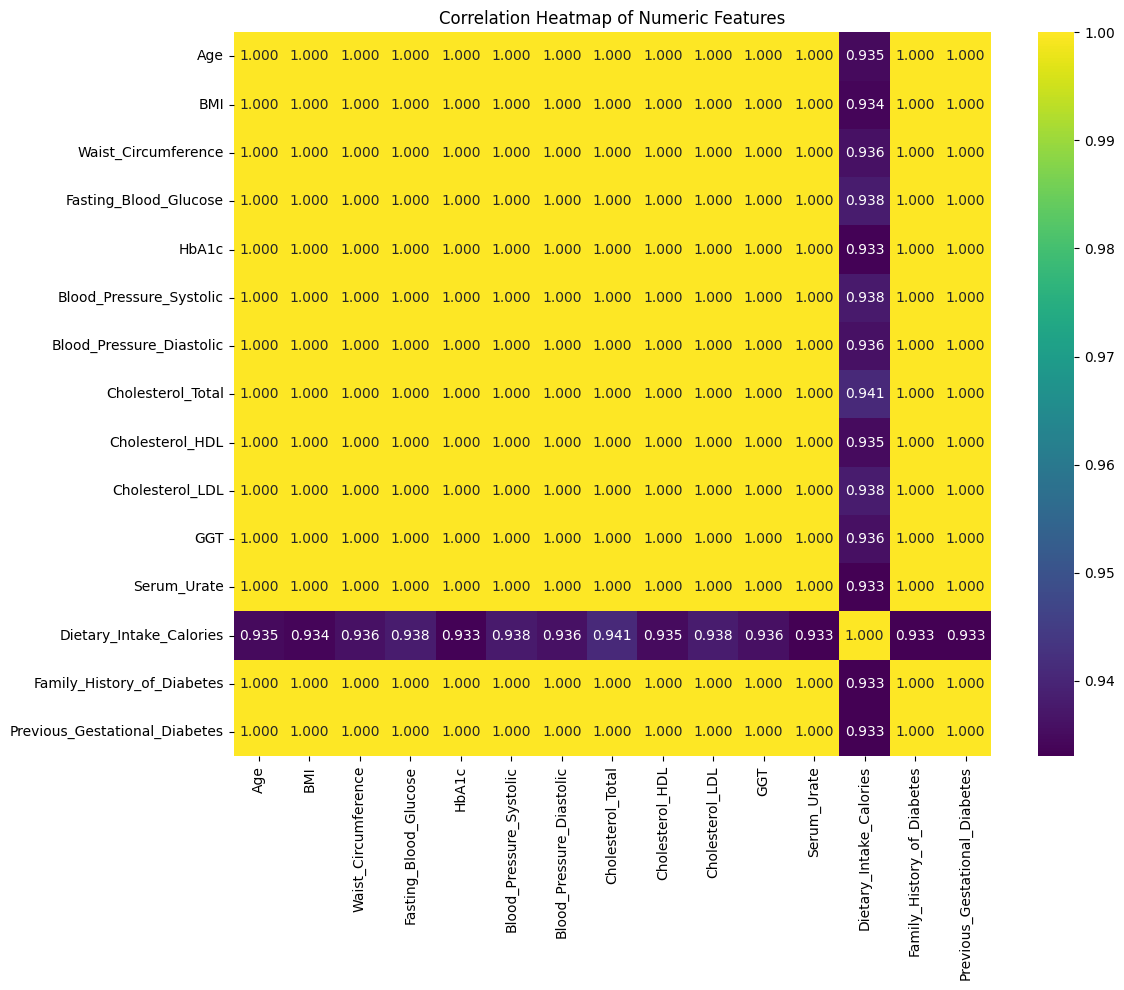

In [11]:
plt.figure(figsize=(12, 10))
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap="viridis", fmt=".3f")
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

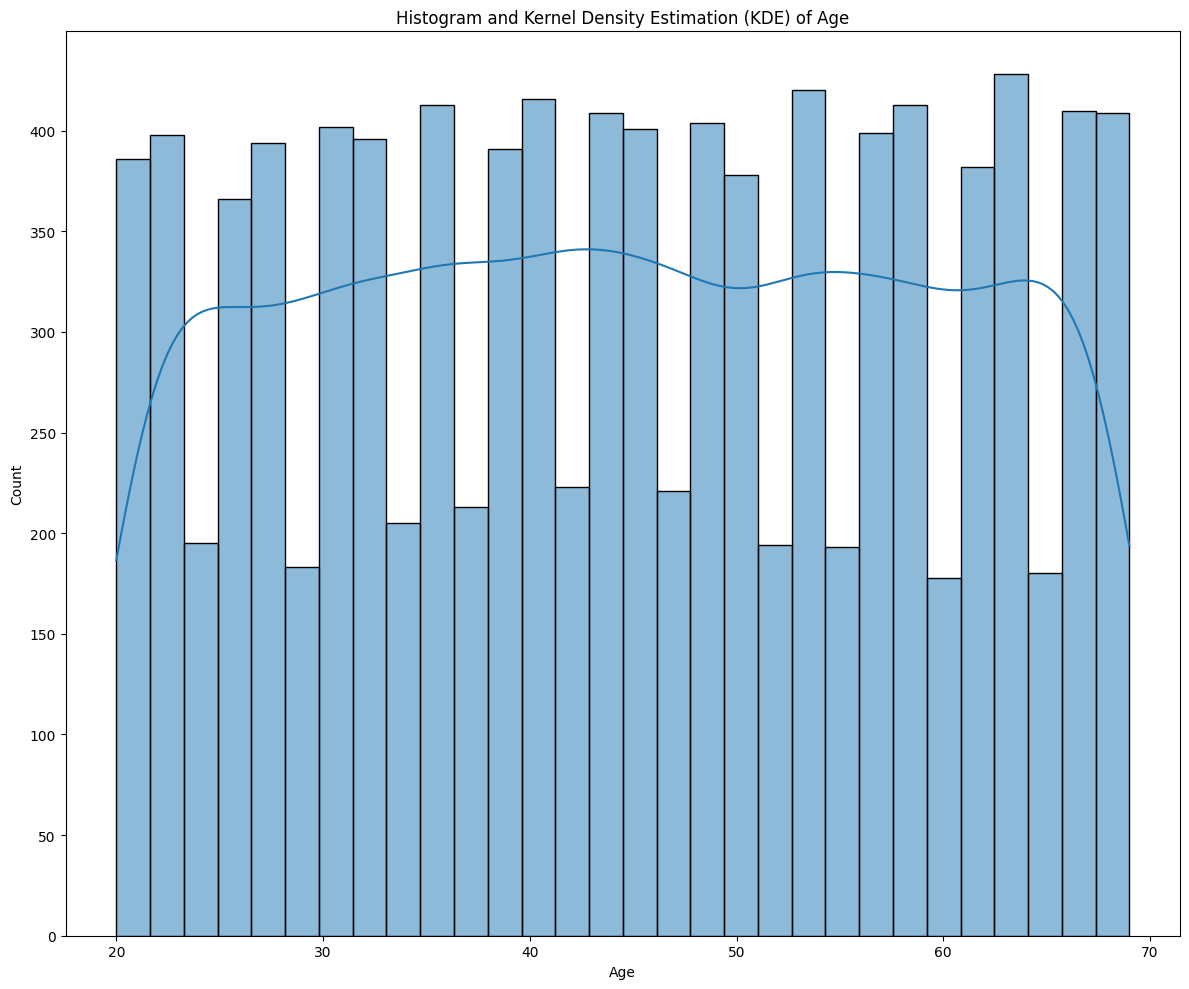

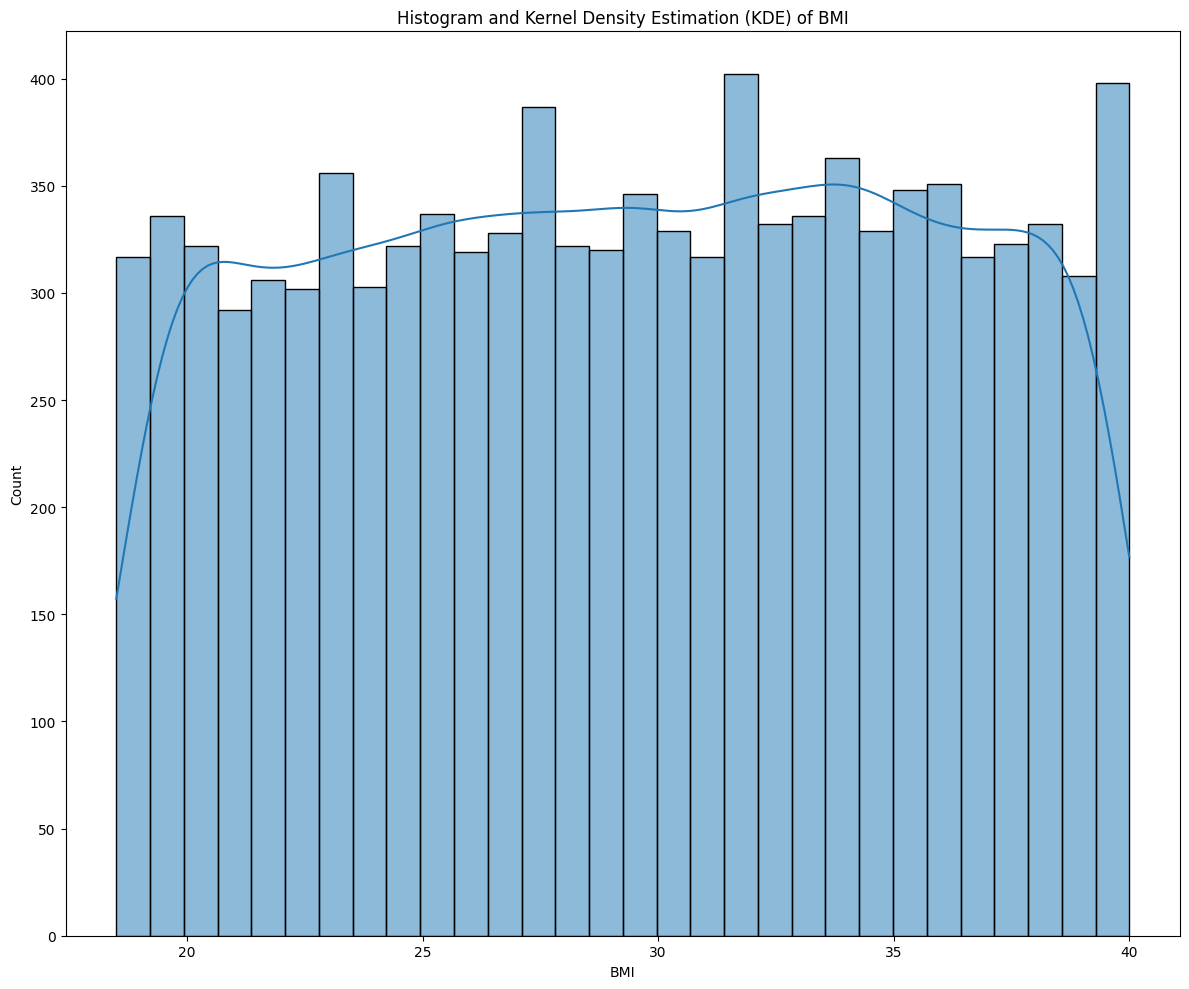

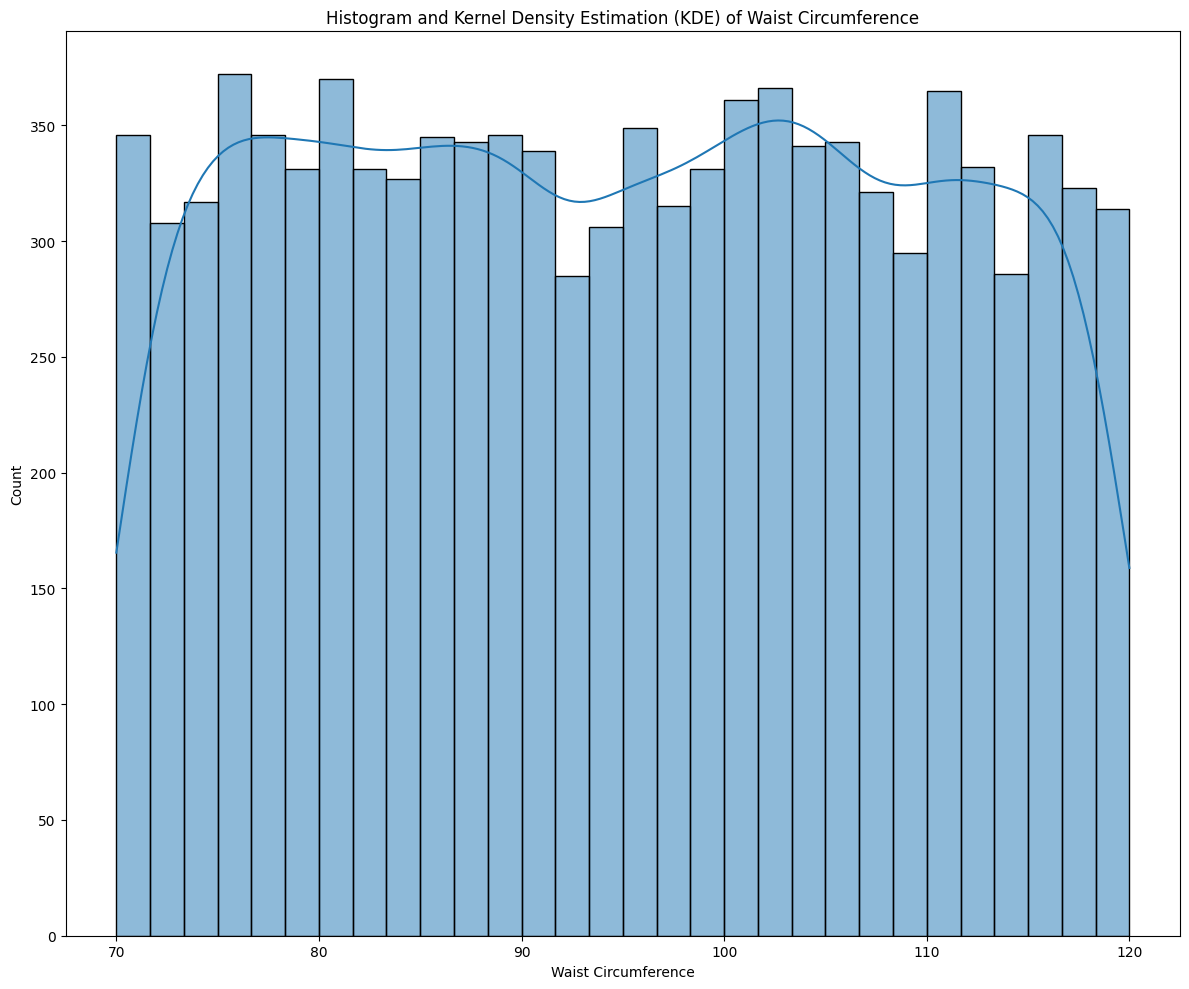

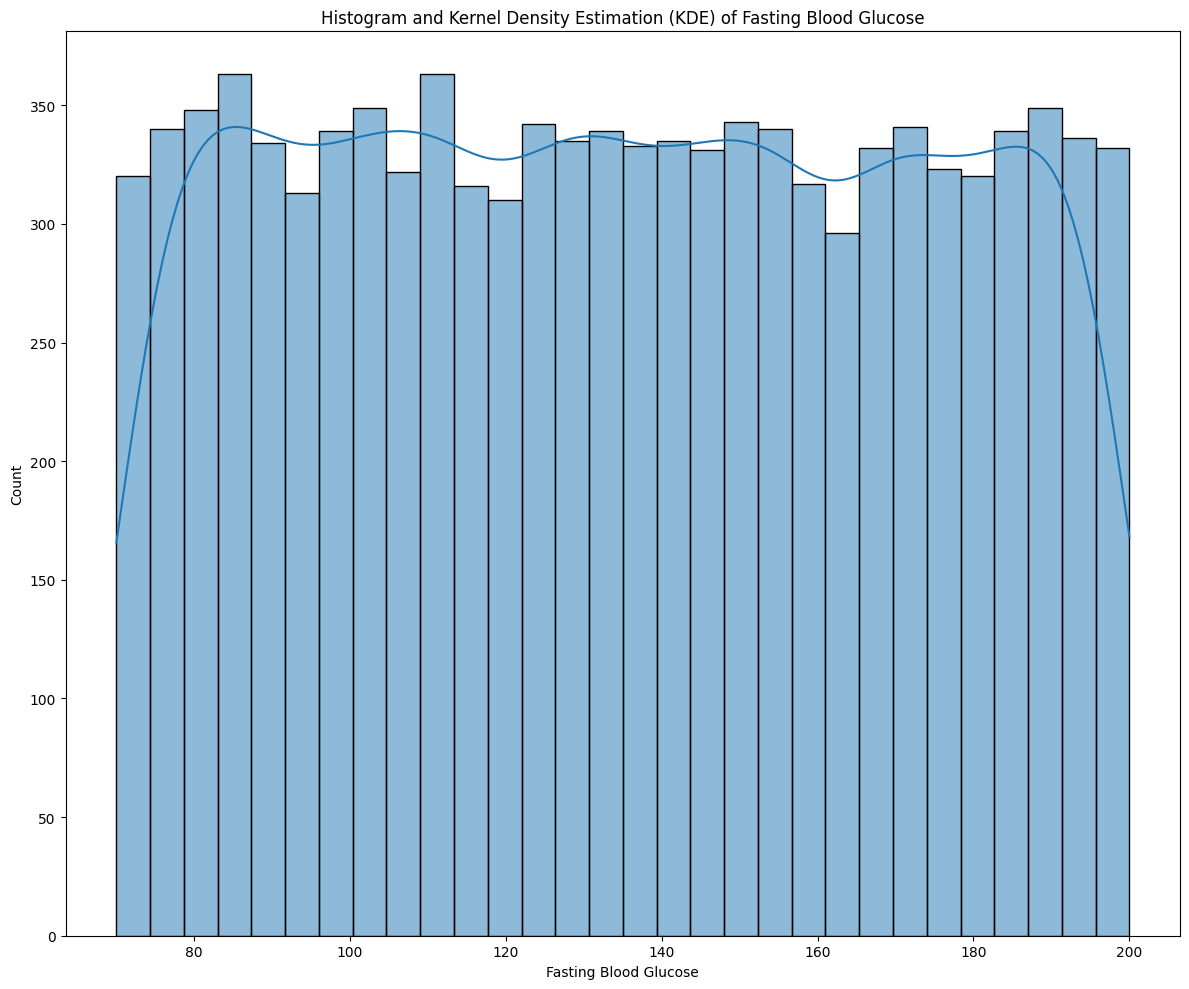

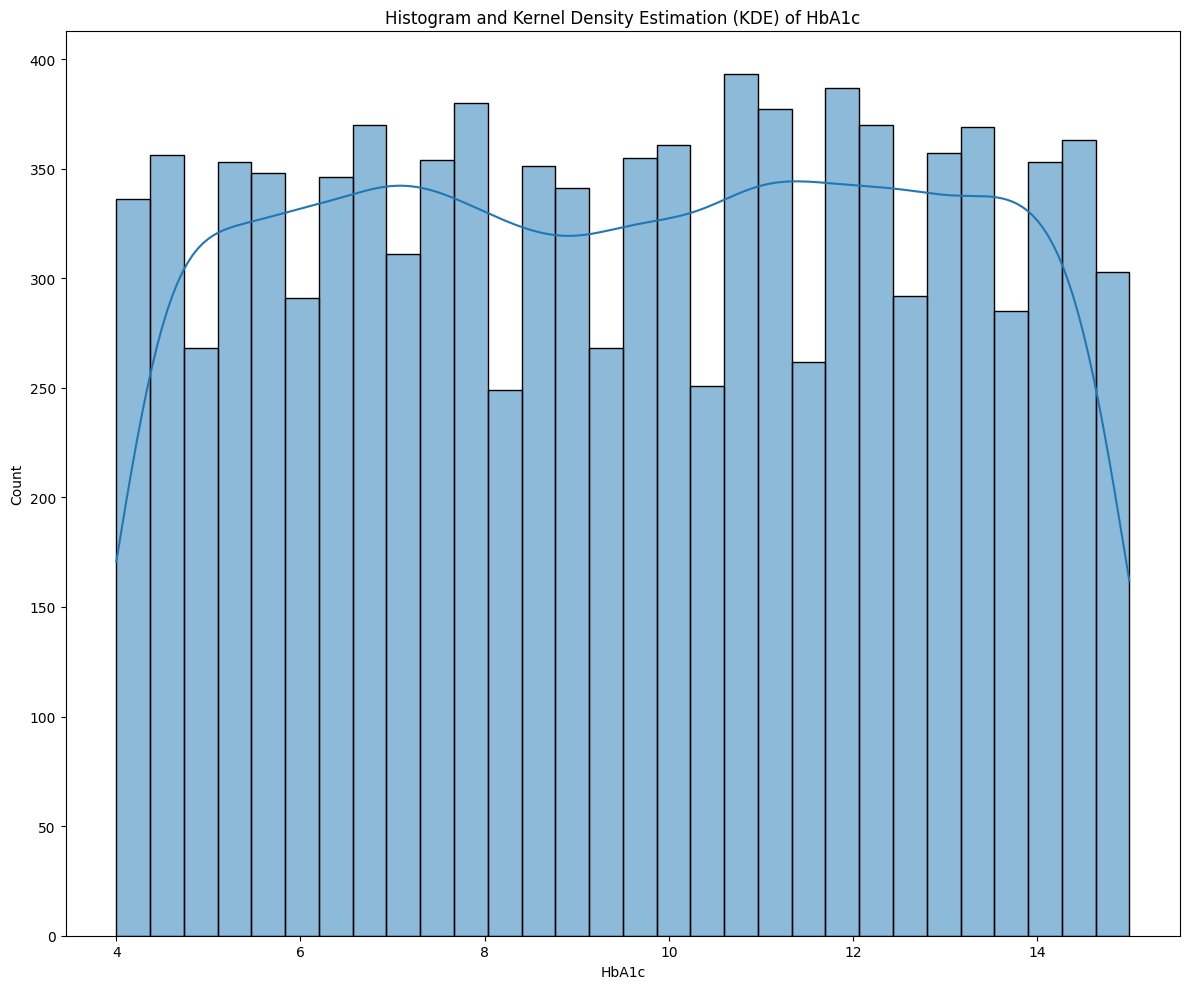

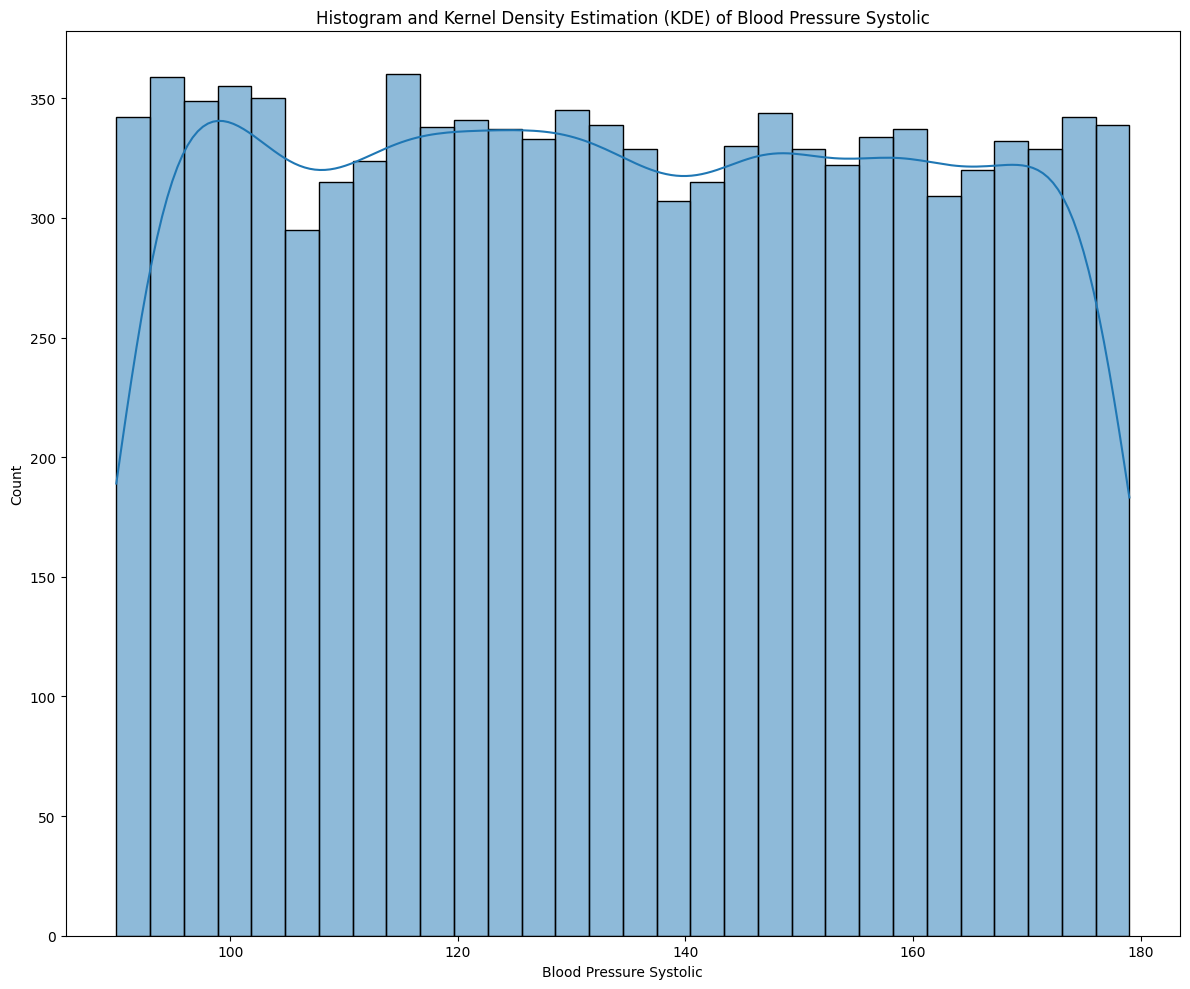

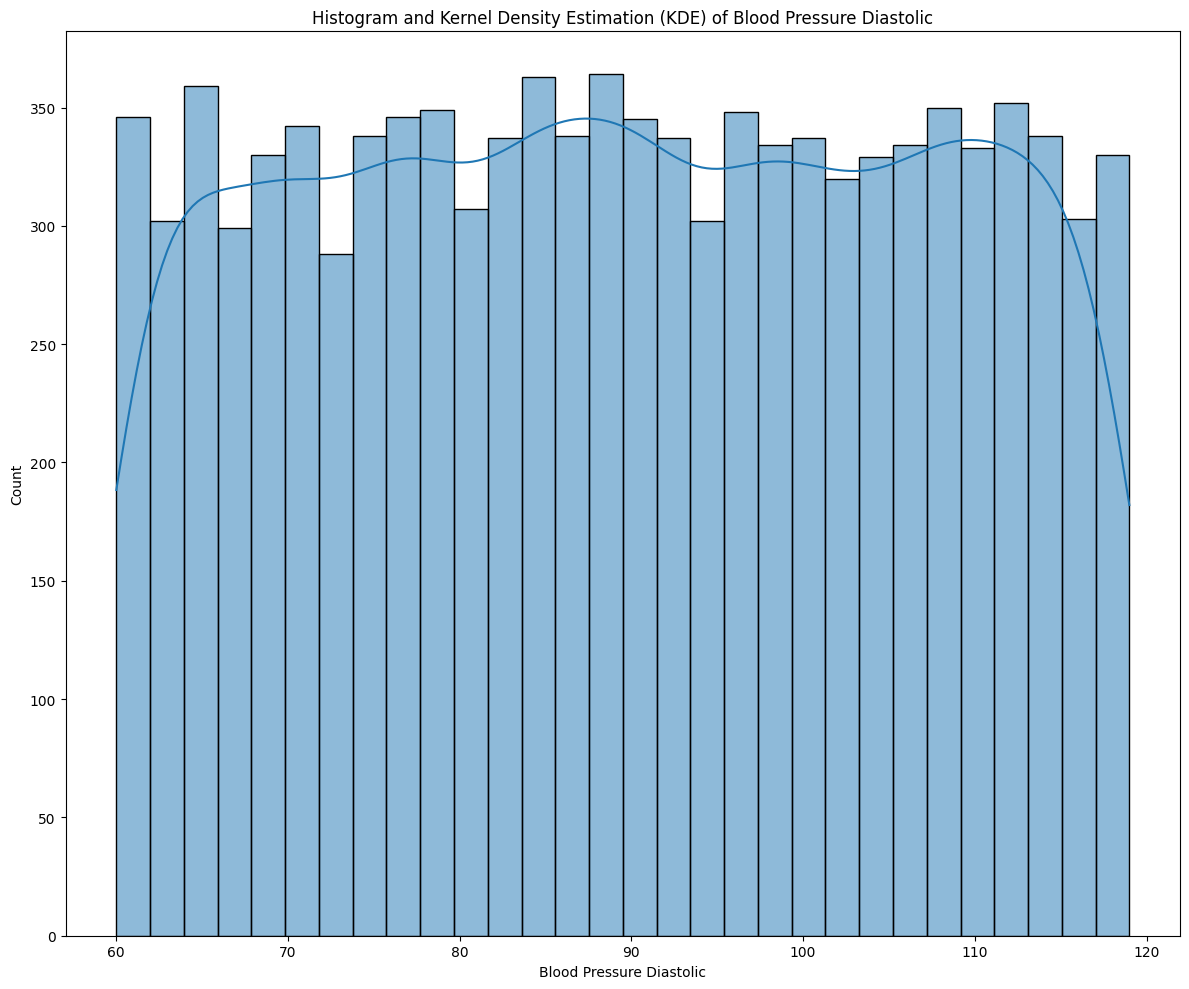

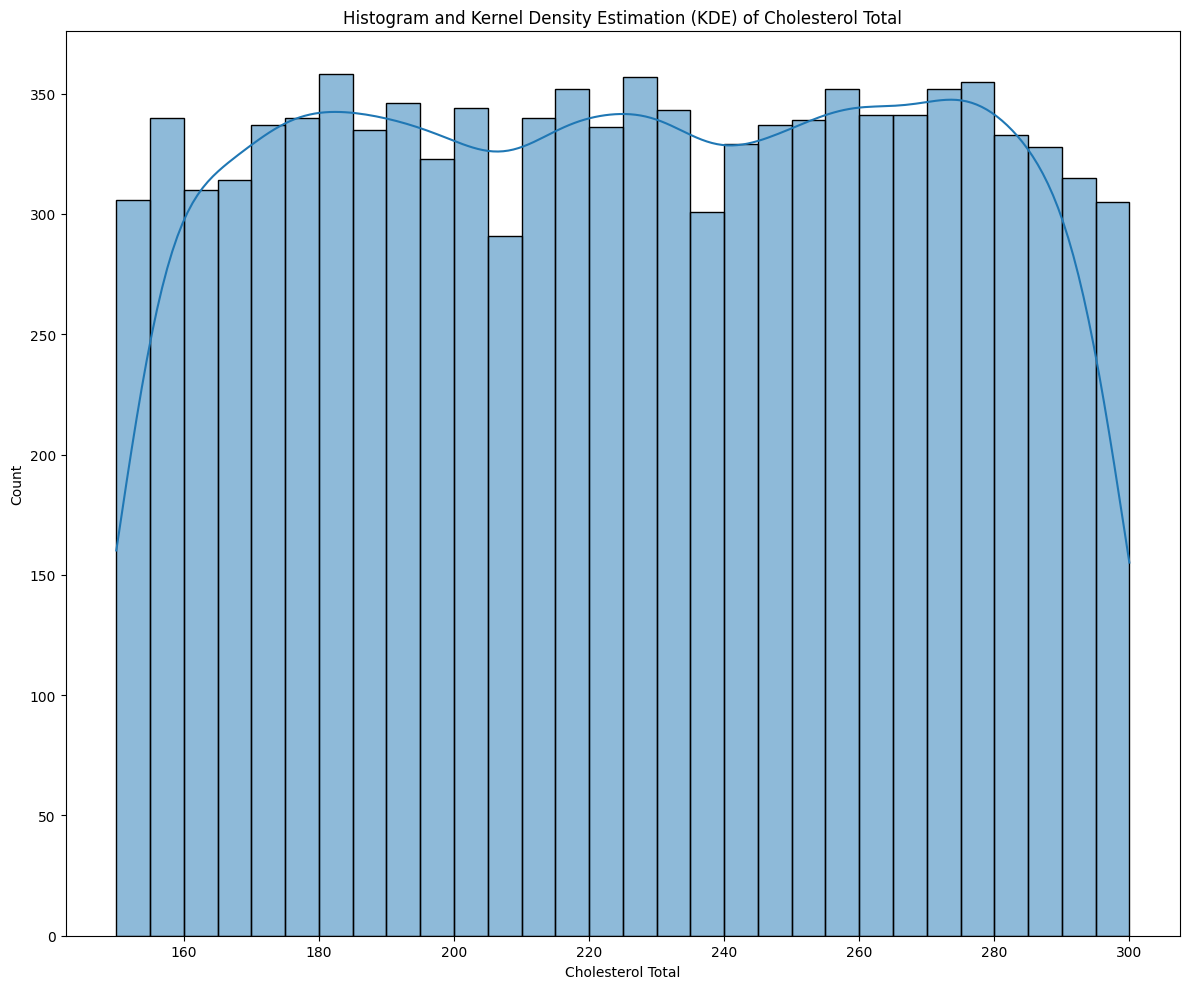

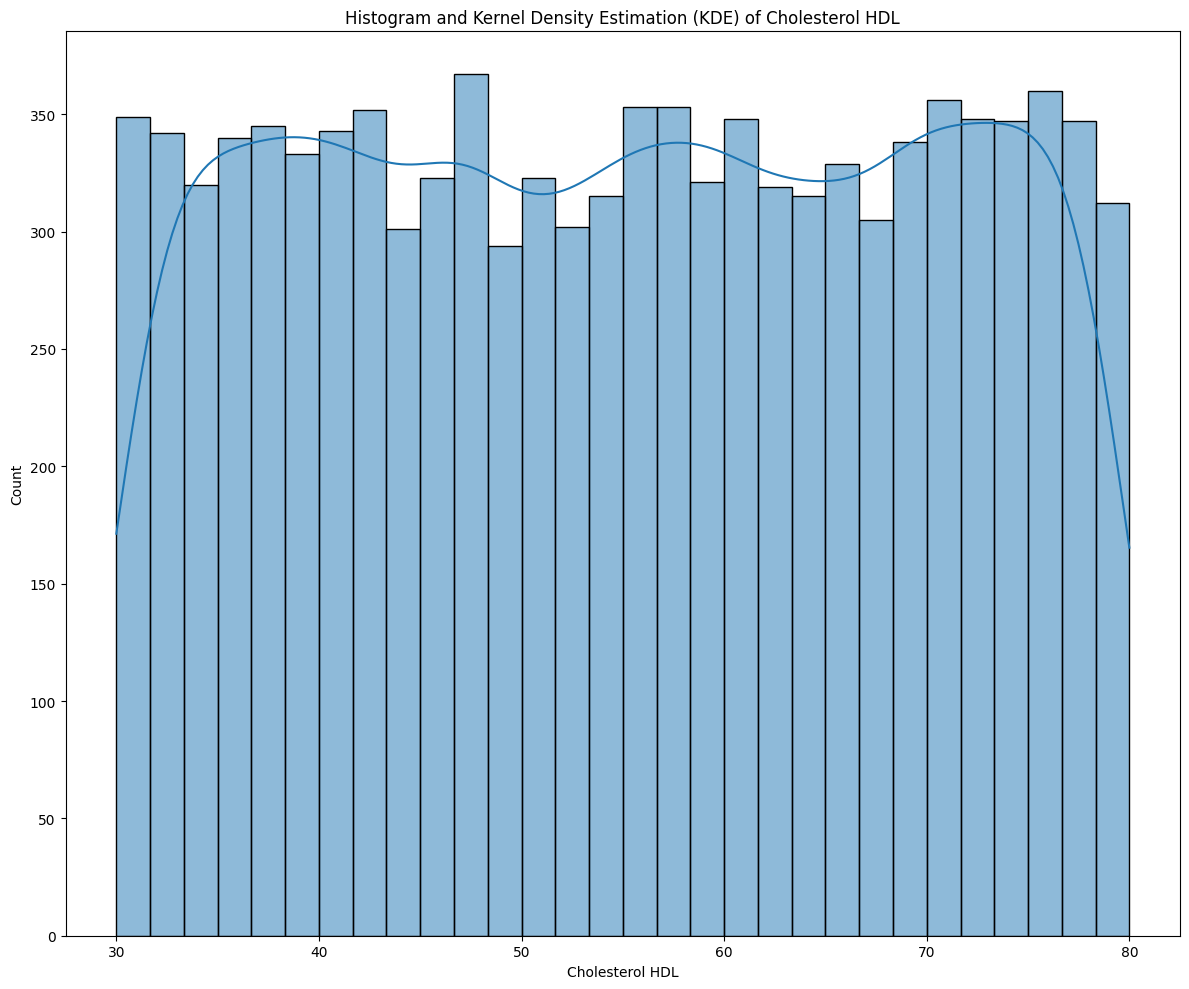

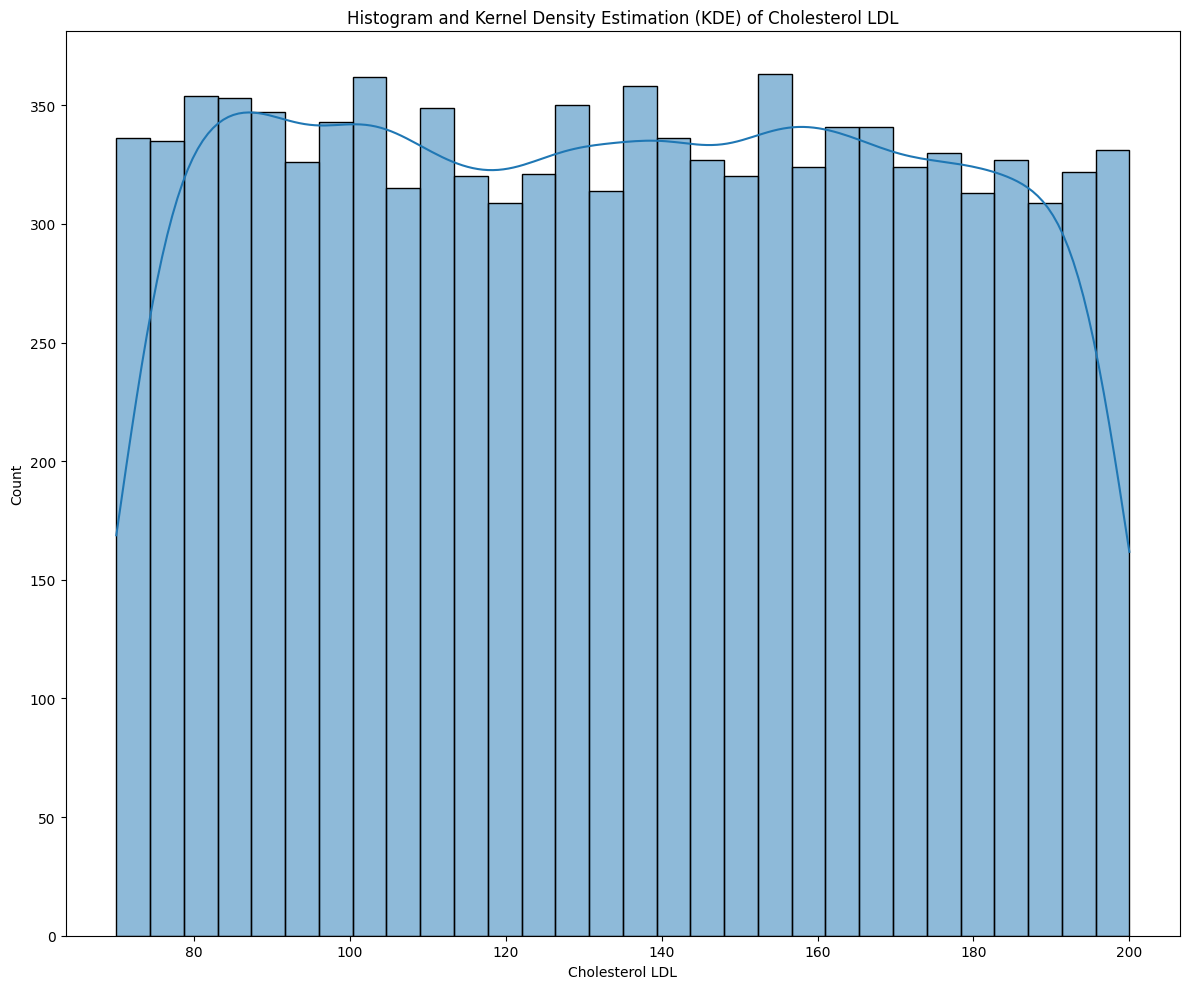

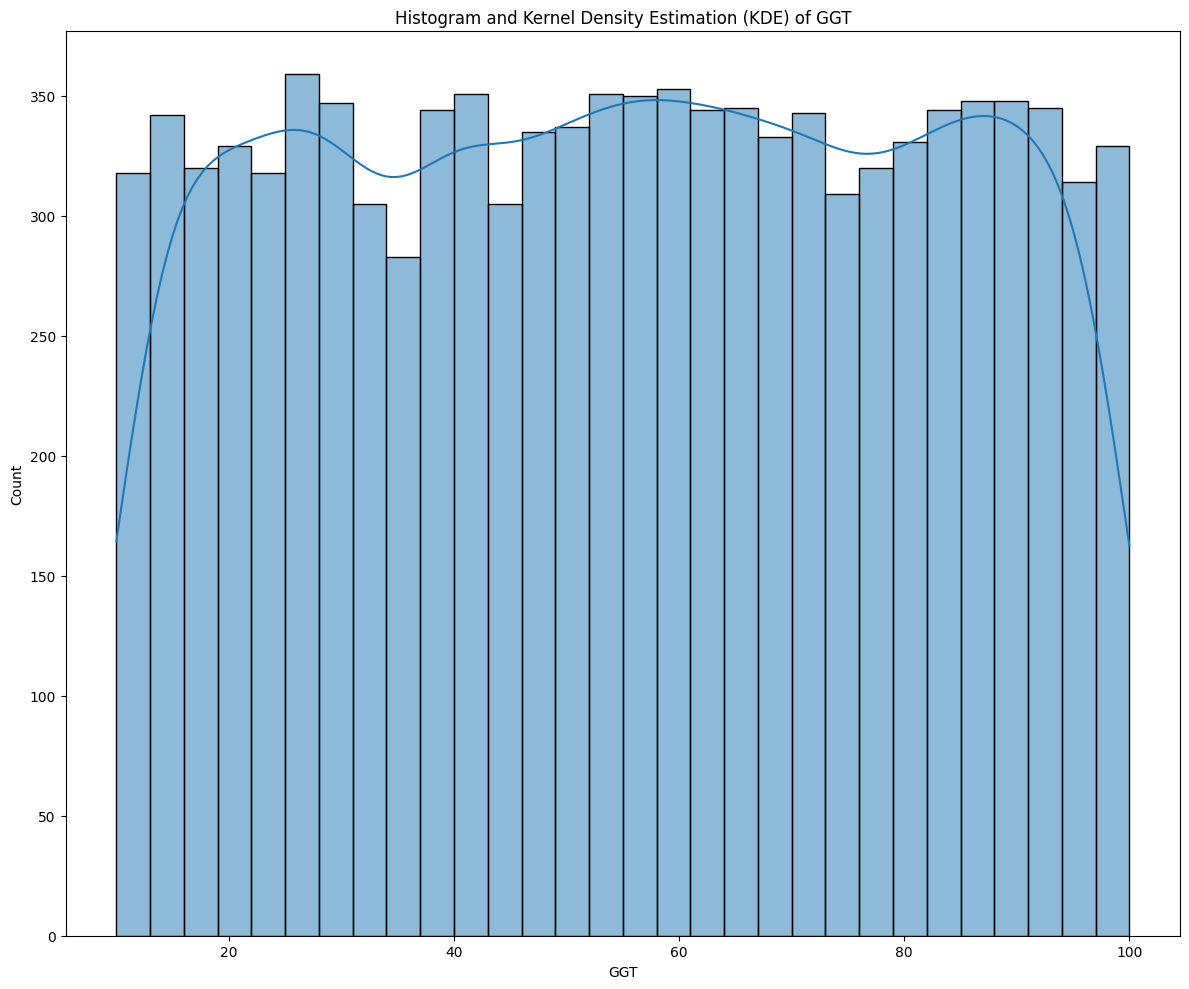

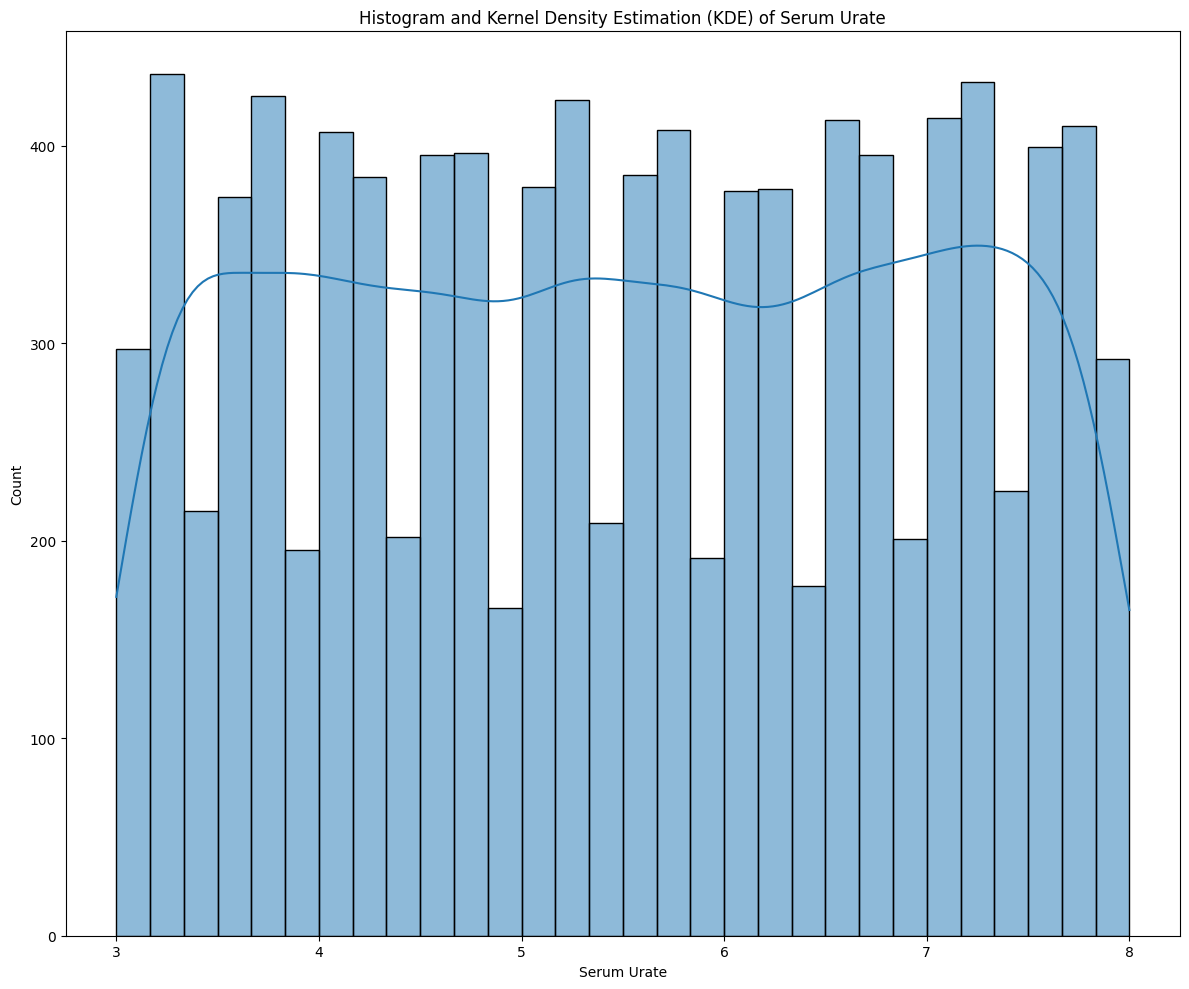

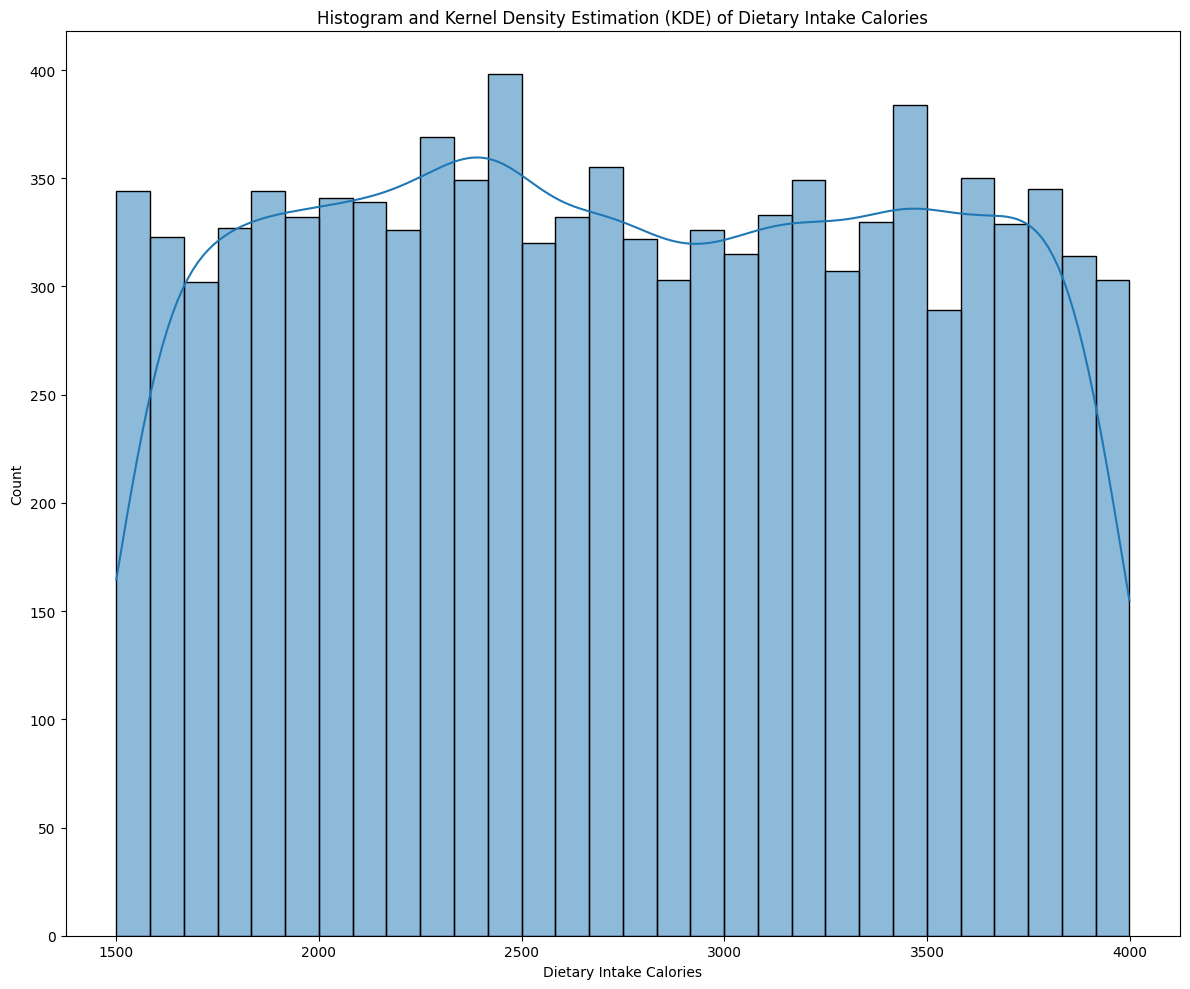

In [12]:
for column in numeric_df.drop(columns=["Family_History_of_Diabetes", "Previous_Gestational_Diabetes"]).columns:
    column_str = column.replace("_", " ")
    plt.figure(figsize=(12, 10))
    sns.histplot(df[column], kde=True, bins=30)
    plt.title(f"Histogram and Kernel Density Estimation (KDE) of {column_str}")
    plt.xlabel(column_str)
    plt.tight_layout()
    plt.show()

In [20]:
#Fasted blood glucose (FBG) - 7mmol/L or above (126 mg/dL or above).
df["Diabetes"] = df["Fasting_Blood_Glucose"].apply(lambda x: 1 if x >= 126 else 0)

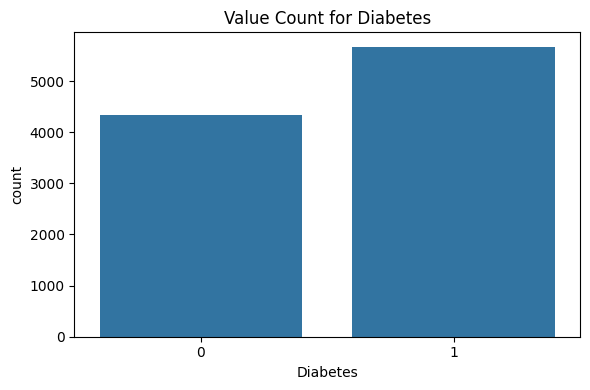

In [25]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Diabetes", data=df)
plt.title("Value Count for Diabetes")
plt.tight_layout()
plt.show()

In [27]:
# Categorical BMI
def classify_bmi(x):
    "https://www.nhs.uk/conditions/obesity/"

    if x < 18.5:
        return "Underweight"

    elif x < 25:
        return "Healthy"

    elif x < 30:
        return "Overweight"

    elif x < 40:
        return "Obese"

    return "Serverly Obese"


df["BMI_Range"] = df["BMI"].apply(classify_bmi)

In [14]:
numeric_features = ["Age", "Waist_Circumference", "HbA1c", "Blood_Pressure_Systolic",
                    "Blood_Pressure_Diastolic", "Cholesterol_Total", "Cholesterol_HDL", "Cholesterol_LDL", "GGT",
                    "Serum_Urate", "Dietary_Intake_Calories", "Family_History_of_Diabetes", "Previous_Gestational_Diabetes"]

onehot_features = ["Sex", "Ethnicity", "Smoking_Status", "Alcohol_Consumption"]
ordinal_features = ["Physical_Activity_Level", "BMI_Range"]

# Fasting_Blood_Glucose column is removed to prevent target leakage and Diabetes column is remove to prevent data leakage
features = numeric_features + onehot_features + ordinal_features
print(f"Number of features: {len(features)}")

Number of features: 19


In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())  # Standardise with mean of zero and standard deviation of one
])

onehot_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore"))  # One hot encoding
])

ordinal_transformer = Pipeline(steps=[
    ("encoder", OrdinalEncoder(categories=[
        ["Low", "Moderate", "High"],
        ["Underweight", "Healthy", "Overweight", "Obese", "Serverly Obese"]
    ]))  # Ordinal encoding
])

# Combine all the preprocessing steps
preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_transformer, numeric_features),
    ("onehot", onehot_transformer, onehot_features),
    ("ordinal", ordinal_transformer, ordinal_features)
])

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            10000 non-null  int64  
 1   Sex                            10000 non-null  object 
 2   Ethnicity                      10000 non-null  object 
 3   BMI                            10000 non-null  float64
 4   Waist_Circumference            10000 non-null  float64
 5   Fasting_Blood_Glucose          10000 non-null  float64
 6   HbA1c                          10000 non-null  float64
 7   Blood_Pressure_Systolic        10000 non-null  int64  
 8   Blood_Pressure_Diastolic       10000 non-null  int64  
 9   Cholesterol_Total              10000 non-null  float64
 10  Cholesterol_HDL                10000 non-null  float64
 11  Cholesterol_LDL                10000 non-null  float64
 12  GGT                            10000 non-null  

In [18]:
TRAIN_SIZE = 0.7
VAL_TEST_SPLIT = 0.5

In [21]:
X = df[features]
y = df["Diabetes"]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, train_size=TRAIN_SIZE, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, train_size=VAL_TEST_SPLIT, stratify=y_temp, random_state=42)

In [22]:
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print(f"Shape of X train: {X_train_processed.shape}. Shape of y train: {y_train.shape}")
print(f"Shape of X val: {X_val_processed.shape}. Shape of y val: {y_val.shape}")
print(f"Shape of X test: {X_test_processed.shape}. Shape of y test: {y_test.shape}")

Shape of X train: (7000, 27). Shape of y train: (7000,)
Shape of X val: (1500, 27). Shape of y val: (1500,)
Shape of X test: (1500, 27). Shape of y test: (1500,)


In [23]:
def evaluate_model(clf, X_val, y_val, class_names=["Non-diabetic", "Diabetic"]):
    y_pred = clf.predict(X_val)

    # Print metrics
    print(classification_report(y_val, y_pred, target_names=class_names))

    # Plot confusion matrix
    cm = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

              precision    recall  f1-score   support

Non-diabetic       0.42      0.47      0.44       650
    Diabetic       0.55      0.51      0.53       850

    accuracy                           0.49      1500
   macro avg       0.49      0.49      0.49      1500
weighted avg       0.50      0.49      0.49      1500



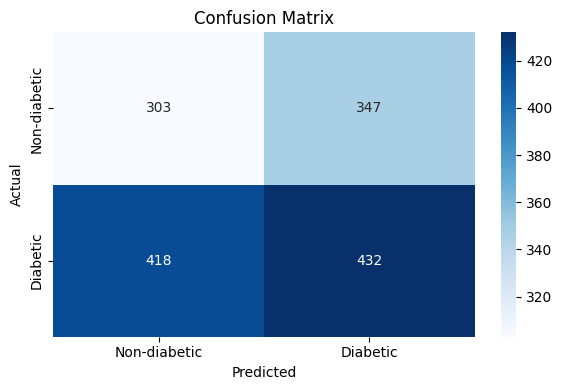

In [24]:
from sklearn.linear_model import LogisticRegression

# Build and train the model
clf = LogisticRegression(max_iter=1000, class_weight="balanced")
clf.fit(X_train_processed, y_train)
evaluate_model(clf, X_val_processed, y_val)

              precision    recall  f1-score   support

Non-diabetic       0.44      0.17      0.24       650
    Diabetic       0.57      0.84      0.68       850

    accuracy                           0.55      1500
   macro avg       0.50      0.50      0.46      1500
weighted avg       0.51      0.55      0.49      1500



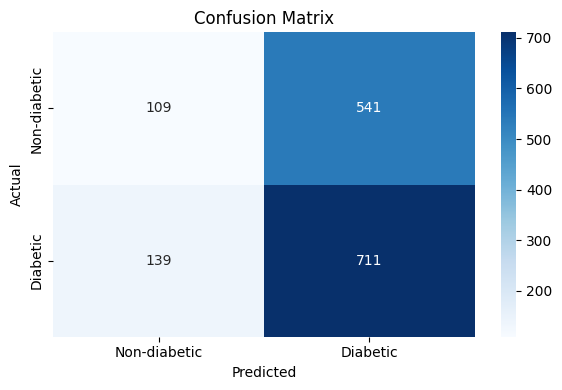

In [25]:
from sklearn.ensemble import RandomForestClassifier

# Build and train the model
clf = RandomForestClassifier(class_weight="balanced")
clf.fit(X_train_processed, y_train)
evaluate_model(clf, X_val_processed, y_val)

              precision    recall  f1-score   support

Non-diabetic       0.42      0.46      0.44       650
    Diabetic       0.55      0.51      0.53       850

    accuracy                           0.49      1500
   macro avg       0.49      0.49      0.49      1500
weighted avg       0.50      0.49      0.49      1500



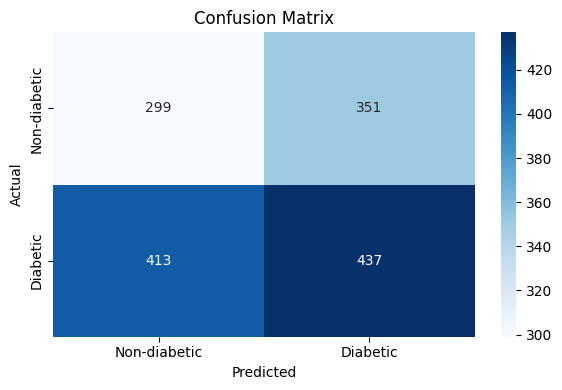

In [26]:
from sklearn.svm import SVC

# Build and train the model
clf = SVC(class_weight="balanced")
clf.fit(X_train_processed, y_train)
evaluate_model(clf, X_val_processed, y_val)